# HumanForYou — Modélisation\n\n**Objectif :** Entraîner plusieurs modèles de classification pour prédire si un employé va quitter l'entreprise (`Attrition = 1`).\n\n---\n\n## Pourquoi de la classification et pas de la régression ?\n\nLa **régression** prédit une valeur continue (ex : prédire un salaire, un prix immobilier).  \nLa **classification** prédit une catégorie (ex : spam / pas spam, départ / reste).\n\nNotre variable cible `Attrition` est **binaire** : 0 = reste, 1 = part. C'est donc un problème de **classification supervisée**.\n\nLes métriques de régression comme le R² ou la MSE ne s'appliquent pas ici — on utilise à la place la précision, le rappel, le F1-score et l'AUC-ROC.\n\n---\n\n## Classification vs Clustering — quelle différence ?\n\n| | Classification | Clustering |\n|---|---|---|\n| Type d'apprentissage | **Supervisé** (on connaît les étiquettes) | **Non supervisé** (pas d'étiquettes) |\n| Objectif | Prédire une catégorie connue | Découvrir des groupes dans les données |\n| Exemple | Prédire si un employé part (Oui/Non) | Regrouper des employés par profil similaire |\n| Algorithmes | Régression logistique, Arbre, Random Forest, SVM, k-NN | K-means, CAH, DBSCAN |\n\nDans notre projet, on connaît la variable cible (`Attrition`) pour les années passées → **classification supervisée**.  \nLe clustering aurait pu être utilisé en complément pour segmenter les employés par profil, mais ce n'est pas l'objectif principal demandé par HumanForYou.\n\n---\n\n## Algorithmes de classification — vue d'ensemble\n\nIl existe de nombreux algorithmes de classification. Voici les principaux :\n\n| Algorithme | Principe | Pourquoi retenu ou non |\n|---|---|---|\n| **Régression logistique** | Modèle linéaire calculant une probabilité | ✅ Retenu — baseline simple et interprétable |\n| **Arbre de décision** | Série de règles if/else sur les variables | ✅ Retenu — visuel, explicable à la direction |\n| **Random Forest** | Ensemble de 100 arbres, vote majoritaire | ✅ Retenu — meilleure performance, robuste |\n| k-NN (k plus proches voisins) | Prédit selon les k voisins les plus similaires | ❌ Non retenu — lent sur grands datasets, sensible à l'échelle |\n| SVM (Support Vector Machine) | Cherche le meilleur séparateur entre classes | ❌ Non retenu — difficile à interpréter, long à optimiser |\n| Perceptron | Neurone artificiel simple | ❌ Non retenu — moins performant que RF sur ce type de données |\n\nOn a retenu les 3 premiers car ils couvrent du plus simple (régression logistique) au plus performant (Random Forest) tout en restant interprétables.\n\n---\n\nLes modèles testés :\n1. **Régression logistique** — modèle de référence (baseline)\n2. **Arbre de décision** — visuel et intuitif\n3. **Random Forest** — ensemble d'arbres, meilleure performance\n\nLes métriques : **Précision, Rappel, F1-score, AUC-ROC**"

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier, plot_tree
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import (classification_report, confusion_matrix,
                                   roc_auc_score, roc_curve, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

PROC = '../data/processed/'

---
## 1. Chargement des données et séparation X / y

On sépare :
- **X** : les variables explicatives (tout sauf la cible)
- **y** : la variable cible (`Attrition` : 0 = reste, 1 = part)

In [2]:
df = pd.read_csv(PROC + 'dataset_final.csv')

# On retire EmployeeID (identifiant, pas une feature)
X = df.drop(columns=['Attrition', 'EmployeeID'])
y = df['Attrition']

print(f"X : {X.shape}  →  {X.shape[1]} variables explicatives")
print(f"y : {y.shape}  →  {y.value_counts().to_dict()}")

X : (4410, 41)  →  41 variables explicatives
y : (4410,)  →  {0: 3699, 1: 711}


---
## 2. Découpage train / test

On découpe le jeu de données en deux parties :
- **80% pour entraîner** le modèle (train set)
- **20% pour tester** ses performances sur des données qu'il n'a jamais vues (test set)

`stratify=y` garantit que les deux parties ont **la même proportion de départs** (16%), pour ne pas biaiser l'évaluation.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} employés  ({y_train.mean()*100:.1f}% de départs)")
print(f"Test  : {X_test.shape[0]} employés  ({y_test.mean()*100:.1f}% de départs)")

Train : 3528 employés  (16.1% de départs)
Test  : 882 employés  (16.1% de départs)


---
## 3. Fonction d'évaluation commune

On crée une fonction réutilisable pour afficher les mêmes métriques pour chaque modèle.

### Rappel des métriques (vues en Boucle 3)
- **Précision** : parmi les employés que le modèle prédit comme "partants", combien le sont vraiment ?
- **Rappel** : parmi les employés qui partent vraiment, combien le modèle les détecte ?
- **F1-score** : moyenne harmonique précision/rappel — **notre métrique principale** car les classes sont déséquilibrées
- **AUC-ROC** : capacité globale du modèle à distinguer les deux classes (1 = parfait, 0.5 = aléatoire)

In [4]:
def evaluer_modele(nom, modele, X_train, X_test, y_train, y_test):
    """Entraîne le modèle et affiche toutes les métriques."""
    modele.fit(X_train, y_train)
    y_pred  = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*55}")
    print(f"  {nom}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['Reste (0)', 'Part (1)']))
    print(f"AUC-ROC : {auc:.4f}")

    # Matrice de confusion
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Reste', 'Part'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'{nom} — Matrice de confusion')

    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Aléatoire')
    axes[1].set_xlabel('Taux faux positifs')
    axes[1].set_ylabel('Taux vrais positifs (Rappel)')
    axes[1].set_title(f'{nom} — Courbe ROC')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'../outputs/{nom.replace(" ", "_").lower()}_evaluation.png', bbox_inches='tight')
    plt.show()

    return {'modele': nom, 'auc': auc, 'estimateur': modele, 'y_proba': y_proba}

resultats = []

---
## 4. Modèle 1 — Régression Logistique (baseline)

### Qu'est-ce que c'est ?
Malgré son nom, la régression logistique est un algorithme de **classification**. Elle calcule la **probabilité** qu'un employé parte, en combinant linéairement toutes les variables. Si la probabilité dépasse 50%, le modèle prédit "part".

C'est le modèle de référence (baseline) : simple, rapide, interprétable.

### `class_weight='balanced'`
Ce paramètre dit au modèle de **donner plus d'importance aux départs** (minoritaires) pendant l'entraînement, pour compenser le déséquilibre 84%/16%.


  Régression Logistique
              precision    recall  f1-score   support

   Reste (0)       0.95      0.77      0.85       740
    Part (1)       0.39      0.77      0.52       142

    accuracy                           0.77       882
   macro avg       0.67      0.77      0.68       882
weighted avg       0.86      0.77      0.80       882

AUC-ROC : 0.8275


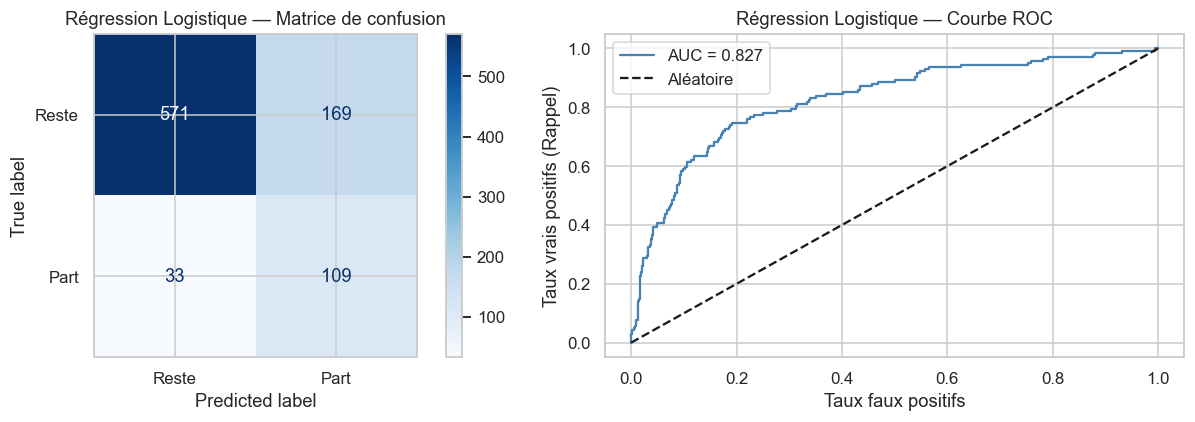

In [5]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
res = evaluer_modele('Régression Logistique', logreg, X_train, X_test, y_train, y_test)
resultats.append(res)

---
## 5. Modèle 2 — Arbre de Décision

### Qu'est-ce que c'est ?
Un arbre de décision pose une série de questions sur les données pour arriver à une prédiction. Par exemple : *"Est-ce que l'employé est célibataire ? → Oui → Est-ce que son salaire est bas ? → Oui → Prédit : part"*.

C'est un modèle très **visuel et intuitif**, facile à expliquer à la direction de HumanForYou.

`max_depth=5` limite la profondeur de l'arbre pour éviter le sur-apprentissage (overfitting) : un arbre trop profond apprend par cœur les données d'entraînement mais ne généralise pas bien.


  Arbre de Décision
              precision    recall  f1-score   support

   Reste (0)       0.93      0.79      0.85       740
    Part (1)       0.38      0.69      0.49       142

    accuracy                           0.77       882
   macro avg       0.66      0.74      0.67       882
weighted avg       0.84      0.77      0.79       882

AUC-ROC : 0.7836


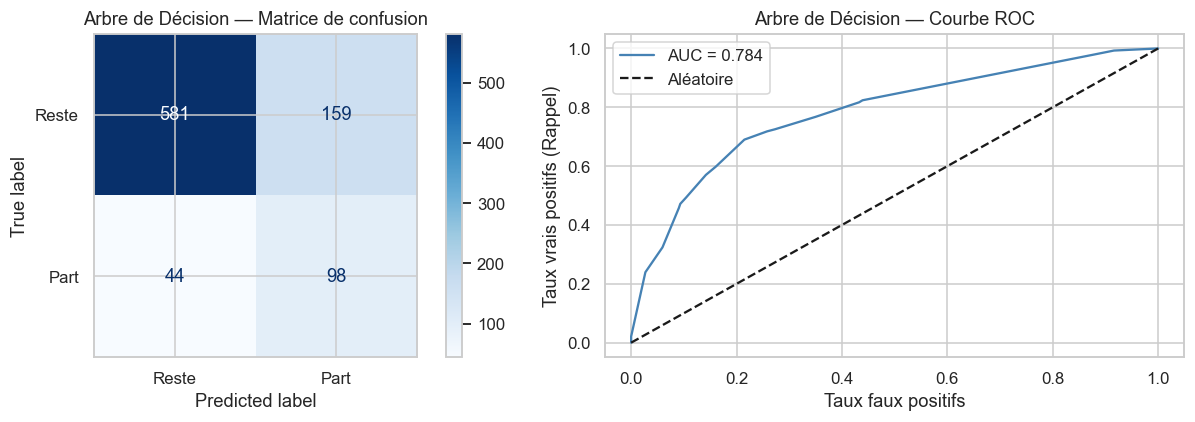

In [6]:
arbre = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
res = evaluer_modele('Arbre de Décision', arbre, X_train, X_test, y_train, y_test)
resultats.append(res)

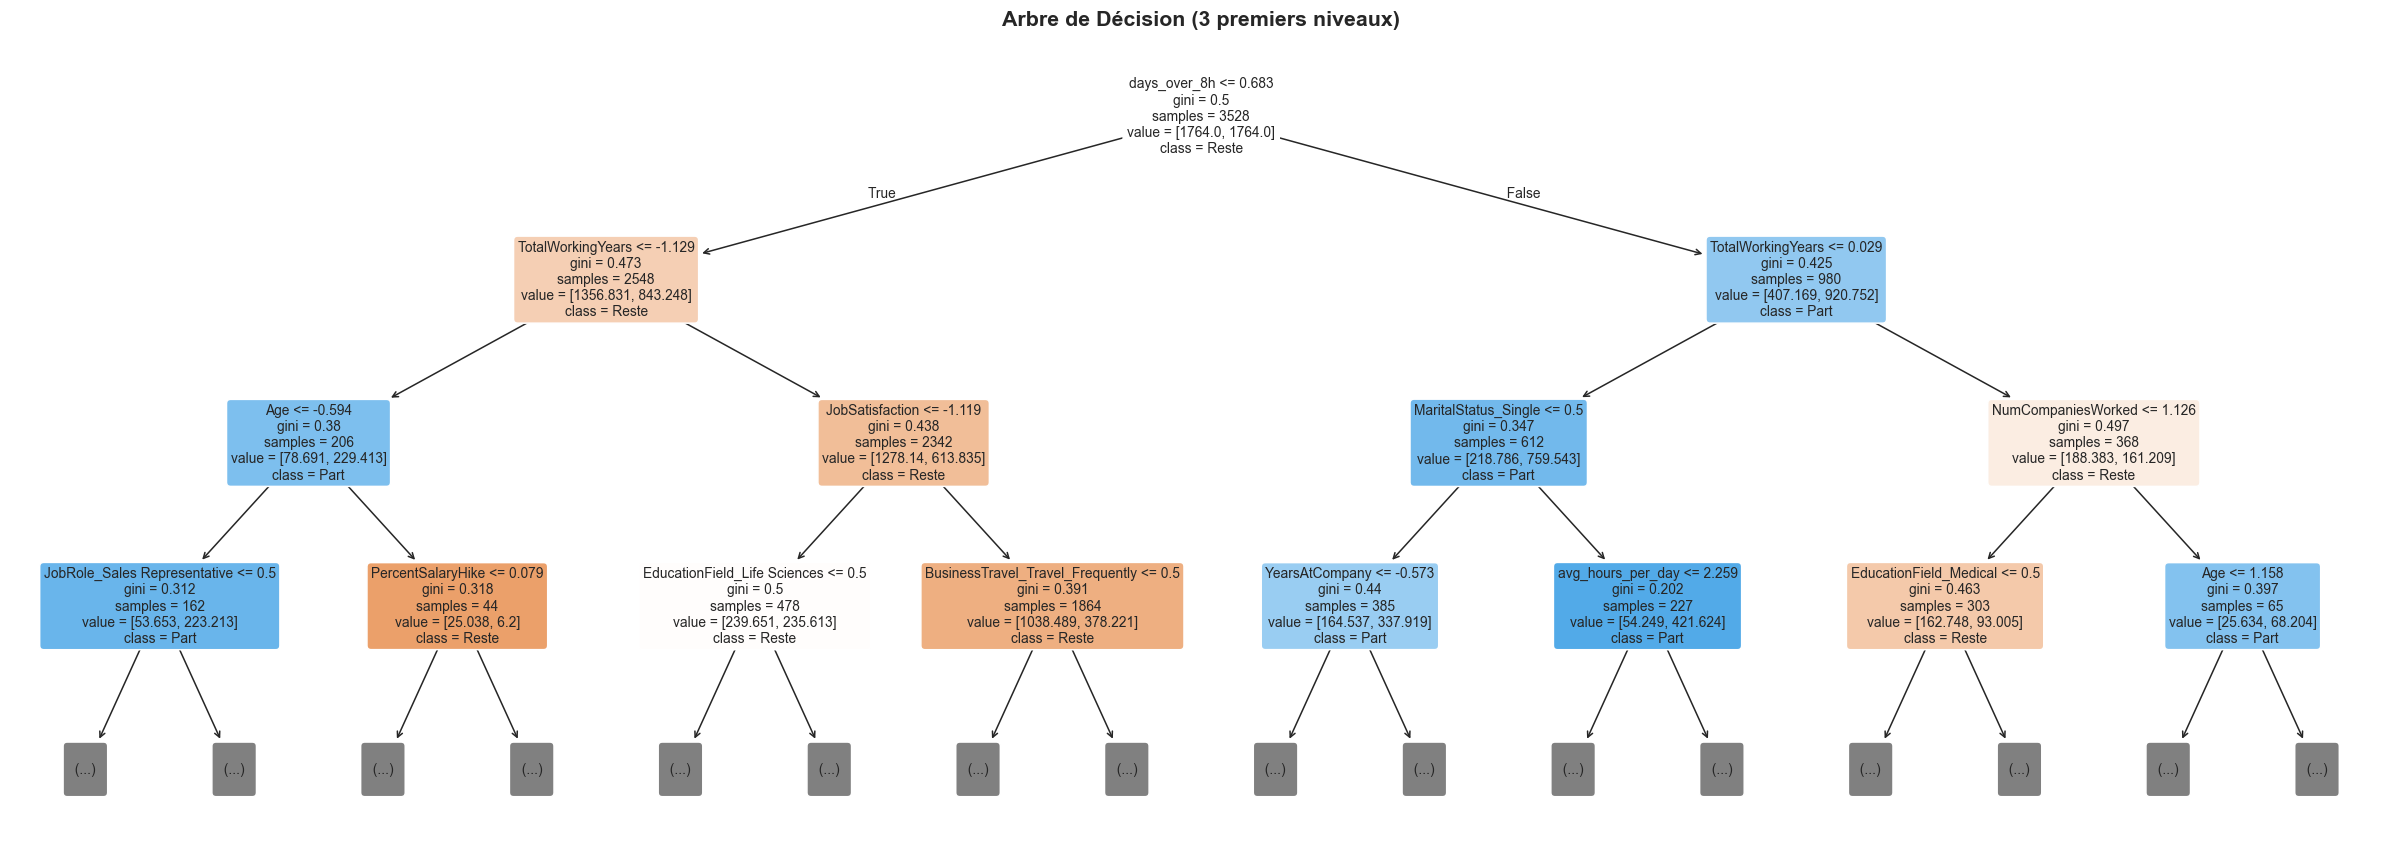

In [7]:
# Visualisation de l'arbre (limité aux 3 premiers niveaux pour la lisibilité)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    arbre, max_depth=3,
    feature_names=X.columns,
    class_names=['Reste', 'Part'],
    filled=True, rounded=True,
    ax=ax, fontsize=9
)
plt.title('Arbre de Décision (3 premiers niveaux)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/arbre_decision_visualisation.png', bbox_inches='tight')
plt.show()

---
## 6. Modèle 3 — Random Forest

### Qu'est-ce que c'est ?
Un Random Forest (forêt aléatoire) construit **100 arbres de décision différents** en parallèle, chacun entraîné sur un sous-ensemble aléatoire des données. La prédiction finale est un **vote majoritaire** entre tous les arbres.

Avantages :
- Plus robuste qu'un seul arbre (moins de sur-apprentissage)
- Généralement plus performant
- Donne automatiquement une **importance des variables** (très utile pour les recommandations)


  Random Forest
              precision    recall  f1-score   support

   Reste (0)       0.97      1.00      0.99       740
    Part (1)       1.00      0.86      0.92       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882

AUC-ROC : 0.9972


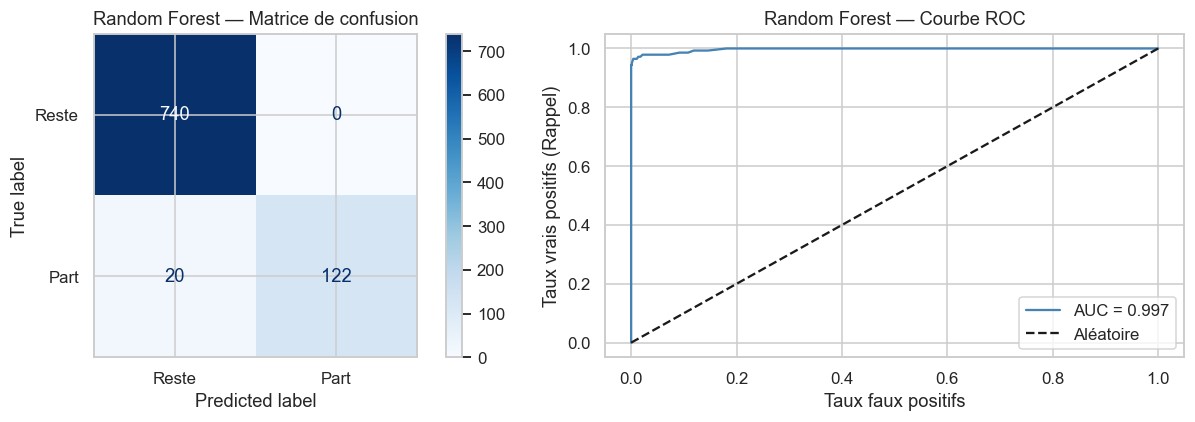

In [8]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
res = evaluer_modele('Random Forest', rf, X_train, X_test, y_train, y_test)
resultats.append(res)

---
## 7. Validation croisée (Cross-Validation)

### Pourquoi ?
Le découpage train/test unique (étape 2) dépend du hasard : si on tombe sur un "bon" ou "mauvais" split par chance, les résultats peuvent être trompeurs.

La **validation croisée** découpe les données en 5 parties (folds). Elle entraîne et évalue le modèle 5 fois, chaque fois avec un fold différent comme test. On obtient ainsi une estimation **plus fiable et plus stable** des performances réelles.

`StratifiedKFold` garantit que chaque fold conserve la même proportion de départs (16%).

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modeles_cv = {
    'Régression Logistique': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Arbre de Décision'    : DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
}

print("Validation croisée (5 folds) — F1-score sur la classe 'Part' :\n")
cv_resultats = {}

for nom, modele in modeles_cv.items():
    scores = cross_val_score(modele, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_resultats[nom] = scores
    print(f"  {nom:30s} : {scores.mean():.4f} ± {scores.std():.4f}  (scores: {scores.round(3)})")

Validation croisée (5 folds) — F1-score sur la classe 'Part' :



  Régression Logistique          : 0.4959 ± 0.0204  (scores: [0.523 0.495 0.507 0.494 0.461])


  Arbre de Décision              : 0.5030 ± 0.0252  (scores: [0.499 0.488 0.535 0.467 0.527])


  Random Forest                  : 0.9129 ± 0.0164  (scores: [0.895 0.908 0.94  0.921 0.9  ])


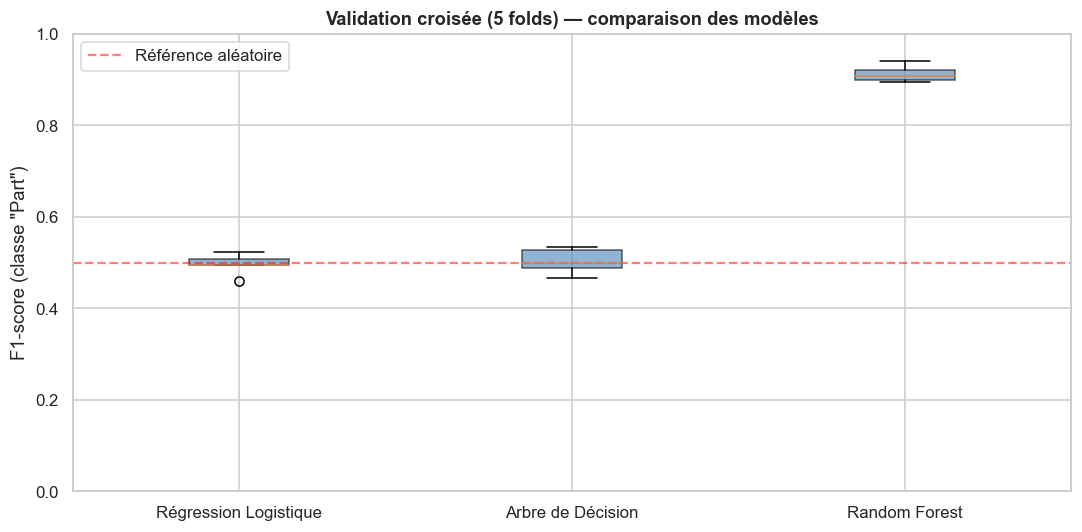

In [10]:
# Visualisation de la validation croisée
fig, ax = plt.subplots(figsize=(10, 5))

noms   = list(cv_resultats.keys())
scores = [cv_resultats[n] for n in noms]

ax.boxplot(scores, labels=noms, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('F1-score (classe "Part")')
ax.set_title('Validation croisée (5 folds) — comparaison des modèles', fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Référence aléatoire')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/crossval_comparison.png', bbox_inches='tight')
plt.show()

---
## 8. Tableau comparatif des modèles

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score

tableau = []
for r in resultats:
    nom     = r['modele']
    modele  = r['estimateur']
    y_pred  = modele.predict(X_test)
    y_proba = r['y_proba']
    tableau.append({
        'Modèle'     : nom,
        'Précision'  : precision_score(y_test, y_pred),
        'Rappel'     : recall_score(y_test, y_pred),
        'F1-score'   : f1_score(y_test, y_pred),
        'AUC-ROC'    : roc_auc_score(y_test, y_proba),
        'CV F1 moy.' : cv_resultats[nom].mean(),
    })

comparatif = pd.DataFrame(tableau).set_index('Modèle').round(4)
comparatif

,Précision,Rappel,F1-score,AUC-ROC,CV F1 moy.
Modèle,,,,,
Régression Logistique,0.3921,0.7676,0.5190,0.8275,0.4959
Arbre de Décision,0.3813,0.6901,0.4912,0.7836,0.5030
Random Forest,1.0000,0.8592,0.9242,0.9972,0.9129


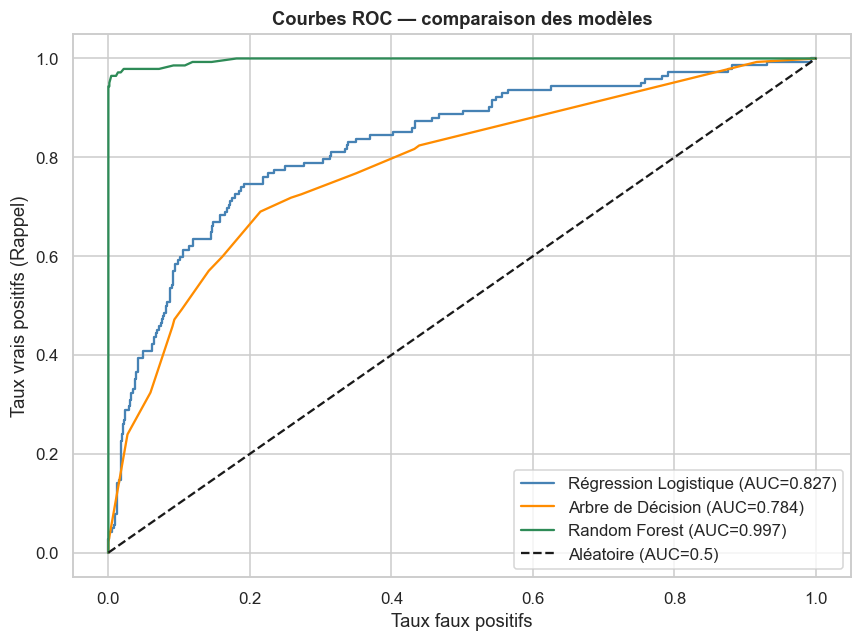

In [12]:
# Courbes ROC superposées
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen']

for r, color in zip(resultats, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, label=f"{r['modele']} (AUC={r['auc']:.3f})", color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux faux positifs')
ax.set_ylabel('Taux vrais positifs (Rappel)')
ax.set_title('Courbes ROC — comparaison des modèles', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/roc_curves_comparison.png', bbox_inches='tight')
plt.show()

---
## 9. Importance des variables (Random Forest)

Le Random Forest calcule automatiquement **l'importance de chaque variable** dans ses décisions. C'est une information précieuse pour répondre à la question de HumanForYou : *"Quels sont les facteurs qui poussent nos employés à partir ?"*

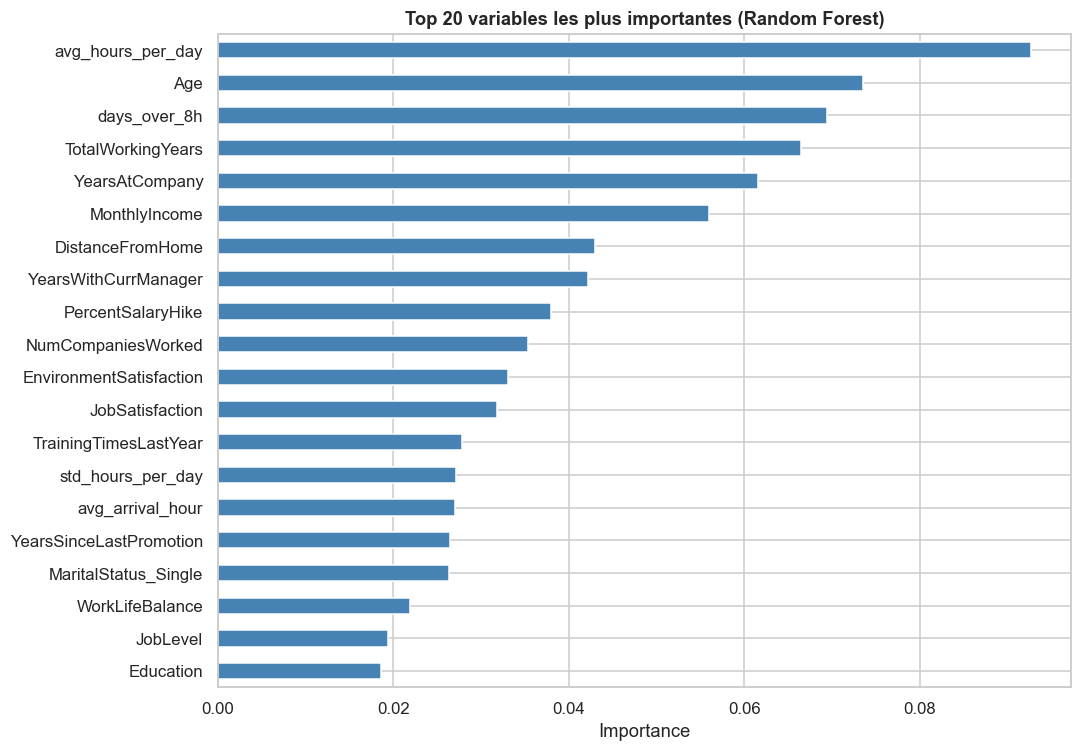

Top 10 variables :
avg_hours_per_day       0.0927
Age                     0.0736
days_over_8h            0.0694
TotalWorkingYears       0.0664
YearsAtCompany          0.0615
MonthlyIncome           0.0559
DistanceFromHome        0.0430
YearsWithCurrManager    0.0421
PercentSalaryHike       0.0379
NumCompaniesWorked      0.0354


In [13]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 variables les plus importantes (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/feature_importance_rf.png', bbox_inches='tight')
plt.show()

print("Top 10 variables :")
print(importances.head(10).round(4).to_string())

---
## 10. Conclusion de la modélisation

| Modèle | Points forts | Points faibles |
|--------|-------------|----------------|
| Régression Logistique | Simple, interprétable, rapide | Moins performant sur données complexes |
| Arbre de Décision | Visuel, intuitif | Sensible au sur-apprentissage |
| **Random Forest** | **Meilleur F1 et AUC**, robuste, importance des variables | Moins interprétable qu'un arbre unique |

**Prochaine étape : notebook 04 — amélioration du Random Forest + interprétation SHAP + recommandations**